In [ ]:
# pip install arch

   ---------------------------------------- 0.0/928.2 kB ? eta -:--:--
   ---------------------------------------- 928.2/928.2 kB 10.6 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


Loaded data shape: (1325, 5)
Columns: ['dlog_SOLVPN', 'dlog_COPPER', 'dlog_DXY', 'd_UST10Y', 'dlog_VIX']
Date range: 2020-10-13 00:00:00 ~ 2026-01-12 00:00:00
Valid rows after univariate GARCH: 1324
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2758.228536958931
            Iterations: 13
            Function evaluations: 50
            Gradient evaluations: 13
Estimated DCC params: alpha=0.020806, beta=0.950757


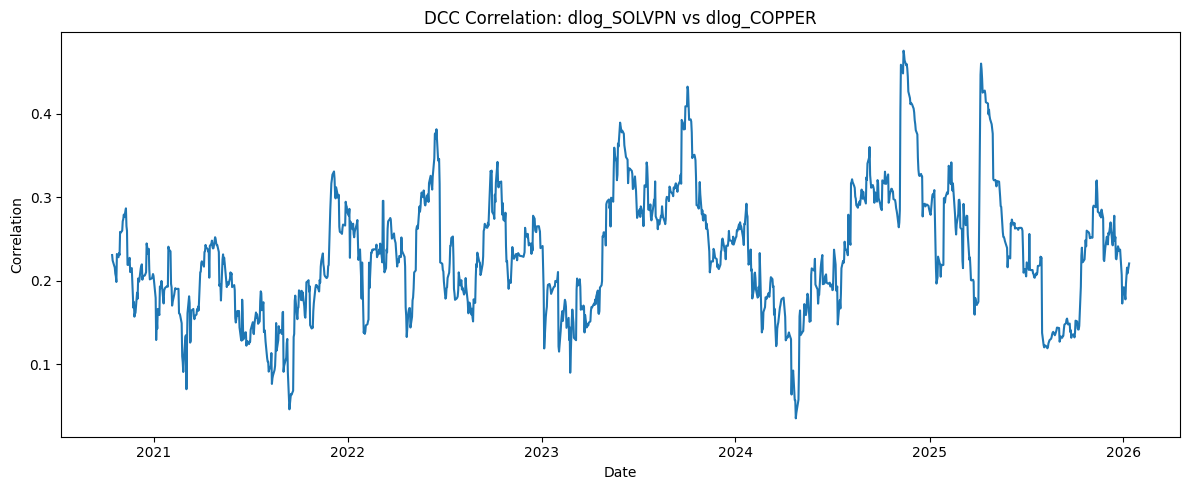

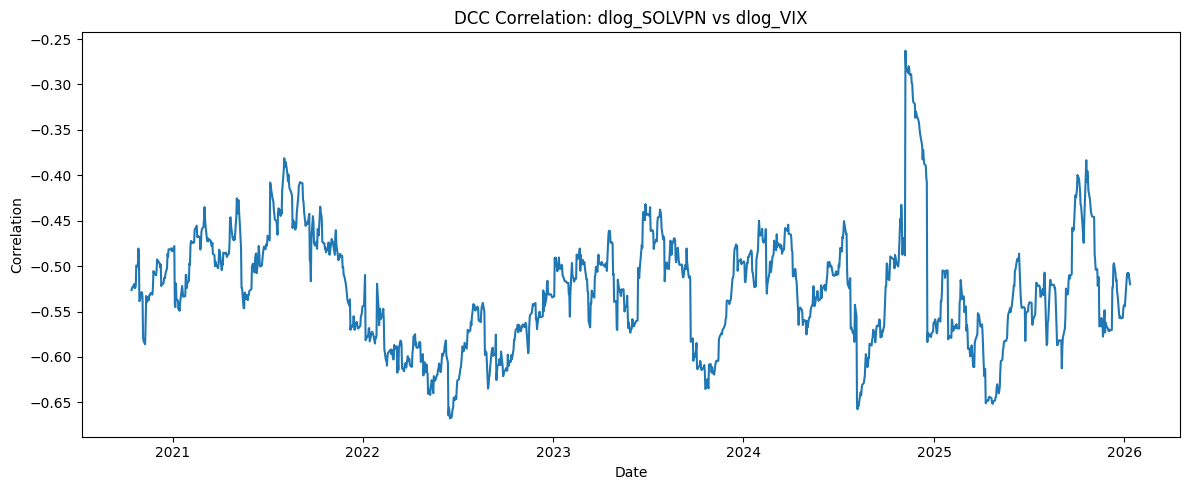

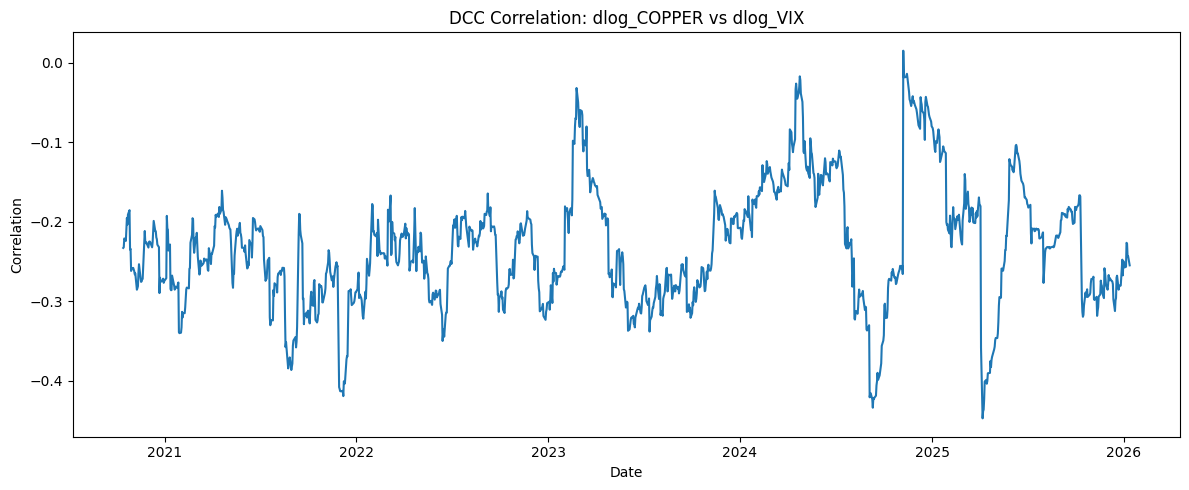

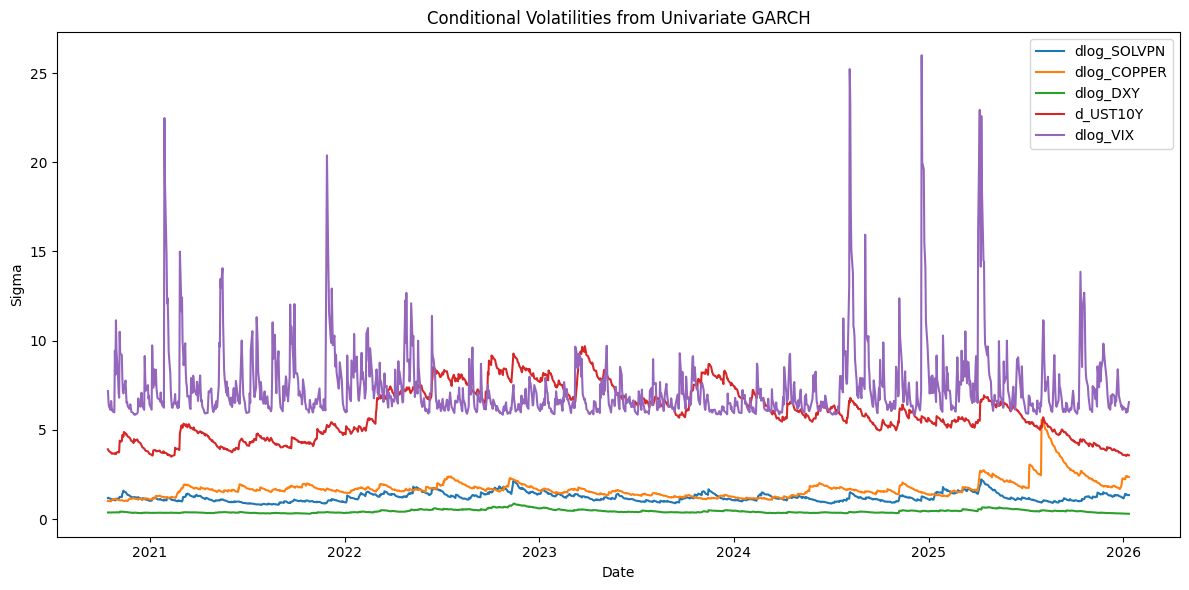


[Done] DCC-GARCH completed.
Output folder: ./output_dcc_garch

Estimated DCC parameters
alpha = 0.020806
beta  = 0.950757

Average correlation matrix
Var2         dlog_SOLVPN  dlog_COPPER  dlog_DXY  d_UST10Y  dlog_VIX
Var1                                                               
dlog_SOLVPN       1.0000       0.2317   -0.2858   -0.2222   -0.5268
dlog_COPPER       0.2317       1.0000   -0.3538    0.0067   -0.2328
dlog_DXY         -0.2858      -0.3538    1.0000    0.3109    0.1716
d_UST10Y         -0.2222       0.0067    0.3109    1.0000    0.0038
dlog_VIX         -0.5268      -0.2328    0.1716    0.0038    1.0000

Pair summary (head)
          Var1         Var2  Corr_Mean  Corr_Std  Corr_Min  Corr_Max  \
0     d_UST10Y  dlog_COPPER   0.006726  0.077334 -0.296063  0.202249   
1     d_UST10Y     dlog_DXY   0.310891  0.105359 -0.048644  0.556521   
2     d_UST10Y  dlog_SOLVPN  -0.222174  0.105919 -0.496249  0.074315   
3     d_UST10Y     dlog_VIX   0.003841  0.112506 -0.285904  0.24

In [3]:
# =========================================================
# DCC-GARCH(1,1) for merged_var_input.csv
# - Input file: ./merged_var_input.csv
# - Uses transformed/stationary columns
# - Step 1: fit univariate GARCH(1,1) for each variable
# - Step 2: estimate DCC(1,1) on standardized residuals
# - Step 3: save dynamic correlation / covariance outputs
# =========================================================

import os
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from arch import arch_model

# =========================================================
# 0. Config
# =========================================================
DATA_PATH = "./merged_var_input.csv"
OUT_DIR = "./output_dcc_garch"

DATE_COL = "Date"
USE_COLS = ["dlog_SOLVPN", "dlog_COPPER", "dlog_DXY", "d_UST10Y", "dlog_VIX"]

# Univariate GARCH settings
MEAN_TYPE = "AR"          # "Zero", "Constant", "AR"
MEAN_LAGS = 1
VOL_TYPE = "GARCH"
P_GARCH = 1
Q_GARCH = 1
DIST = "normal"           # "normal", "t"

# Plot pairs
PLOT_PAIRS = [
    ("dlog_SOLVPN", "dlog_COPPER"),
    ("dlog_SOLVPN", "dlog_VIX"),
    ("dlog_COPPER", "dlog_VIX"),
]

os.makedirs(OUT_DIR, exist_ok=True)

# =========================================================
# 1. Load data
# =========================================================
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"File not found: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)

required_cols = [DATE_COL] + USE_COLS
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")

df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df = df.sort_values(DATE_COL).reset_index(drop=True)
df = df[required_cols].dropna().reset_index(drop=True)

dates = df[DATE_COL].copy()
X = df[USE_COLS].copy()

# arch_model usually behaves better on scaled return series
X_scaled = X * 100.0

T, N = X_scaled.shape
print("Loaded data shape:", X_scaled.shape)
print("Columns:", USE_COLS)
print("Date range:", dates.min(), "~", dates.max())

# Save cleaned input
clean_df = pd.concat([dates, X_scaled], axis=1)
clean_df.to_csv(os.path.join(OUT_DIR, "dcc_input_clean_scaled.csv"), index=False)

# =========================================================
# 2. Univariate GARCH fits
# =========================================================
std_resids = []
cond_vols = []
uni_summary = []
fit_details = {}

for col in USE_COLS:
    series = X_scaled[col].astype(float)

    am = arch_model(
        series,
        mean=MEAN_TYPE,
        lags=MEAN_LAGS if MEAN_TYPE == "AR" else 0,
        vol=VOL_TYPE,
        p=P_GARCH,
        q=Q_GARCH,
        dist=DIST,
        rescale=False
    )

    res = am.fit(disp="off")

    resid = pd.Series(res.resid, index=series.index)
    sigma = pd.Series(res.conditional_volatility, index=series.index)
    z = resid / sigma

    std_resids.append(z.values)
    cond_vols.append(sigma.values)

    params_dict = {}
    for k, v in res.params.items():
        try:
            params_dict[k] = float(v)
        except Exception:
            params_dict[k] = str(v)

    uni_summary.append({
        "Variable": col,
        "AIC": float(res.aic),
        "BIC": float(res.bic),
        "LogLik": float(res.loglikelihood),
        "MeanType": MEAN_TYPE,
        "VolType": VOL_TYPE,
        "P_GARCH": P_GARCH,
        "Q_GARCH": Q_GARCH,
        "Dist": DIST
    })

    fit_details[col] = {
        "params": params_dict
    }

Z = np.column_stack(std_resids)      # standardized residuals
H_uni = np.column_stack(cond_vols)   # conditional volatilities

# Remove rows with NaN/inf after AR-GARCH fitting
valid_mask = np.isfinite(Z).all(axis=1) & np.isfinite(H_uni).all(axis=1)
Z = Z[valid_mask]
H_uni = H_uni[valid_mask]
dates2 = dates.loc[valid_mask].reset_index(drop=True)

T2 = len(dates2)
if T2 < 50:
    raise ValueError(f"Too few valid observations after GARCH fitting: {T2}")

print("Valid rows after univariate GARCH:", T2)

uni_df = pd.DataFrame(uni_summary)
uni_df.to_csv(os.path.join(OUT_DIR, "univariate_garch_summary.csv"), index=False)

with open(os.path.join(OUT_DIR, "univariate_garch_params.json"), "w", encoding="utf-8") as f:
    json.dump(fit_details, f, ensure_ascii=False, indent=2)

# Save standardized residuals and vols
std_resid_df = pd.DataFrame(Z, columns=[f"z_{c}" for c in USE_COLS])
std_resid_df.insert(0, DATE_COL, dates2)
std_resid_df.to_csv(os.path.join(OUT_DIR, "standardized_residuals.csv"), index=False)

cond_vol_df = pd.DataFrame(H_uni, columns=[f"sigma_{c}" for c in USE_COLS])
cond_vol_df.insert(0, DATE_COL, dates2)
cond_vol_df.to_csv(os.path.join(OUT_DIR, "conditional_volatilities.csv"), index=False)

# =========================================================
# 3. DCC log-likelihood
# =========================================================
S = np.cov(Z.T)
S = (S + S.T) / 2

# numerical stabilization
min_diag = 1e-8
diag_S = np.diag(S).copy()
diag_S[diag_S < min_diag] = min_diag
np.fill_diagonal(S, diag_S)

def make_corr_from_Q(Q):
    d = np.sqrt(np.diag(Q))
    d[d < 1e-12] = 1e-12
    D_inv = np.diag(1.0 / d)
    R = D_inv @ Q @ D_inv
    R = (R + R.T) / 2
    return R

def dcc_neg_loglik(params, Z, S):
    a, b = params

    if a < 0 or b < 0 or a + b >= 0.999:
        return 1e12

    T, N = Z.shape
    Q_t = S.copy()
    nll = 0.0

    for t in range(T):
        if t > 0:
            z_prev = Z[t - 1].reshape(-1, 1)
            Q_t = (1.0 - a - b) * S + a * (z_prev @ z_prev.T) + b * Q_t

        R_t = make_corr_from_Q(Q_t)

        try:
            sign, logdet = np.linalg.slogdet(R_t)
            if sign <= 0:
                return 1e12

            invR = np.linalg.pinv(R_t)
            z_t = Z[t].reshape(-1, 1)
            quad = float(z_t.T @ invR @ z_t)
            nll += logdet + quad
        except Exception:
            return 1e12

    return 0.5 * nll

# =========================================================
# 4. Estimate DCC parameters
# =========================================================
x0 = np.array([0.03, 0.95], dtype=float)
bounds = [(1e-6, 0.5), (1e-6, 0.999)]
constraints = [{"type": "ineq", "fun": lambda x: 0.999 - x[0] - x[1]}]

opt = minimize(
    dcc_neg_loglik,
    x0=x0,
    args=(Z, S),
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
    options={"maxiter": 1000, "disp": True}
)

if not opt.success:
    print("Optimization message:", opt.message)

a_hat, b_hat = opt.x
print(f"Estimated DCC params: alpha={a_hat:.6f}, beta={b_hat:.6f}")

# =========================================================
# 5. Reconstruct dynamic R_t and H_t
# =========================================================
Q_t = S.copy()
R_list = []
H_list = []
pair_records = []
full_corr_records = []
full_cov_records = []

for t in range(T2):
    if t > 0:
        z_prev = Z[t - 1].reshape(-1, 1)
        Q_t = (1.0 - a_hat - b_hat) * S + a_hat * (z_prev @ z_prev.T) + b_hat * Q_t

    R_t = make_corr_from_Q(Q_t)
    R_list.append(R_t)

    D_t = np.diag(H_uni[t])
    H_t = D_t @ R_t @ D_t
    H_list.append(H_t)

    # pairwise long format
    for i in range(N):
        for j in range(N):
            pair_records.append({
                "Date": dates2.iloc[t],
                "Var1": USE_COLS[i],
                "Var2": USE_COLS[j],
                "DCC_Corr": float(R_t[i, j]),
                "Covariance": float(H_t[i, j])
            })

    # full wide correlation
    corr_row = {"Date": dates2.iloc[t]}
    cov_row = {"Date": dates2.iloc[t]}
    for i in range(N):
        for j in range(N):
            corr_row[f"corr__{USE_COLS[i]}__{USE_COLS[j]}"] = float(R_t[i, j])
            cov_row[f"cov__{USE_COLS[i]}__{USE_COLS[j]}"] = float(H_t[i, j])
    full_corr_records.append(corr_row)
    full_cov_records.append(cov_row)

pair_df = pd.DataFrame(pair_records)
corr_wide_df = pd.DataFrame(full_corr_records)
cov_wide_df = pd.DataFrame(full_cov_records)

pair_df.to_csv(os.path.join(OUT_DIR, "dcc_dynamic_pairs_long.csv"), index=False)
corr_wide_df.to_csv(os.path.join(OUT_DIR, "dcc_dynamic_correlation_wide.csv"), index=False)
cov_wide_df.to_csv(os.path.join(OUT_DIR, "dcc_dynamic_covariance_wide.csv"), index=False)

# =========================================================
# 6. Average correlation matrix
# =========================================================
avg_corr = (
    pair_df.groupby(["Var1", "Var2"])["DCC_Corr"]
    .mean()
    .unstack()
    .reindex(index=USE_COLS, columns=USE_COLS)
)
avg_cov = (
    pair_df.groupby(["Var1", "Var2"])["Covariance"]
    .mean()
    .unstack()
    .reindex(index=USE_COLS, columns=USE_COLS)
)

avg_corr.to_csv(os.path.join(OUT_DIR, "dcc_average_correlation_matrix.csv"))
avg_cov.to_csv(os.path.join(OUT_DIR, "dcc_average_covariance_matrix.csv"))

# =========================================================
# 7. Pair summaries
# =========================================================
pair_summary = (
    pair_df[pair_df["Var1"] != pair_df["Var2"]]
    .groupby(["Var1", "Var2"])
    .agg(
        Corr_Mean=("DCC_Corr", "mean"),
        Corr_Std=("DCC_Corr", "std"),
        Corr_Min=("DCC_Corr", "min"),
        Corr_Max=("DCC_Corr", "max"),
        Cov_Mean=("Covariance", "mean"),
        Cov_Std=("Covariance", "std"),
        Cov_Min=("Covariance", "min"),
        Cov_Max=("Covariance", "max"),
    )
    .reset_index()
    .sort_values(["Var1", "Var2"])
)
pair_summary.to_csv(os.path.join(OUT_DIR, "dcc_pair_summary.csv"), index=False)

# =========================================================
# 8. Metadata
# =========================================================
meta = {
    "model": "DCC-GARCH(1,1)",
    "data_path": DATA_PATH,
    "date_col": DATE_COL,
    "use_cols": USE_COLS,
    "mean_type": MEAN_TYPE,
    "mean_lags": MEAN_LAGS,
    "vol_type": VOL_TYPE,
    "p_garch": P_GARCH,
    "q_garch": Q_GARCH,
    "dist": DIST,
    "dcc_alpha": float(a_hat),
    "dcc_beta": float(b_hat),
    "n_obs_raw": int(T),
    "n_obs_used": int(T2)
}
with open(os.path.join(OUT_DIR, "metadata.json"), "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2, default=str)

# =========================================================
# 9. Plots
# =========================================================
def plot_pair_corr(pair_df, var1, var2, out_dir):
    tmp = pair_df[(pair_df["Var1"] == var1) & (pair_df["Var2"] == var2)].copy()
    tmp["Date"] = pd.to_datetime(tmp["Date"])

    plt.figure(figsize=(12, 5))
    plt.plot(tmp["Date"], tmp["DCC_Corr"])
    plt.title(f"DCC Correlation: {var1} vs {var2}")
    plt.xlabel("Date")
    plt.ylabel("Correlation")
    plt.tight_layout()
    fname = f"dcc_corr_{var1}_vs_{var2}.png".replace("/", "_")
    plt.savefig(os.path.join(out_dir, fname), dpi=300)
    plt.show()

def plot_cond_vols(cond_vol_df, use_cols, out_dir):
    plt.figure(figsize=(12, 6))
    for col in use_cols:
        plt.plot(pd.to_datetime(cond_vol_df[DATE_COL]), cond_vol_df[f"sigma_{col}"], label=col)
    plt.title("Conditional Volatilities from Univariate GARCH")
    plt.xlabel("Date")
    plt.ylabel("Sigma")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "univariate_conditional_volatilities.png"), dpi=300)
    plt.show()

for v1, v2 in PLOT_PAIRS:
    if v1 in USE_COLS and v2 in USE_COLS:
        plot_pair_corr(pair_df, v1, v2, OUT_DIR)

plot_cond_vols(cond_vol_df, USE_COLS, OUT_DIR)

# =========================================================
# 10. Print summary
# =========================================================
print("\n[Done] DCC-GARCH completed.")
print("Output folder:", OUT_DIR)
print("\nEstimated DCC parameters")
print(f"alpha = {a_hat:.6f}")
print(f"beta  = {b_hat:.6f}")

print("\nAverage correlation matrix")
print(avg_corr.round(4))

print("\nPair summary (head)")
print(pair_summary.head())